<img src="https://spire.com/wp-content/themes/spire2021/img/spire-global-cubesat-satellite-logo.svg" width="170">

# Spire AI-S2S on Earthmover — live daily + hindcast, after the September 2026 repairs

Two Arraylake repos hold Spire's AI sub-seasonal (SAIFS S2S) statistics:

| Repo | What it is | Slots |
| :--- | :--- | :--- |
| **`Spire/saifs-s2s-daily`** | the live product: the most recent issuances, refreshed every day | 15-slot rolling window |
| **`Spire/saifs-s2s-hindcast`** | the archive: every issuance since 2026-01-01, filled 30 days behind real time | date-anchored, one slot per day |

Both are Icechunk stores imported into Arraylake straight from Spire's S3 buckets, so what you read here is what the pipelines wrote, with no copy in between.

### What this notebook checks

In September 2026 two defects were found and repaired:

1. **Dropped leads in the live store** (fixed 2026-09-15). For several months the publish step silently dropped roughly half of every issuance's 46 lead files. A dropped lead kept the *previous* occupant of the rolling slot (the issuance from 15 days earlier) under the new issuance date.
2. **Stale cells inherited by the hindcast** (repaired 2026-09-15/16). The hindcast had recovered 113 issuances from the live store's history and inherited those stale cells: 77 issuances, 1,979 (issuance, lead) cells. The 81 issuances with no archived GRIBs were **re-run** at OSC and re-ingested.

We use the same diagnostics that found the problem to confirm the fix, live against both stores: lead-to-lead continuity, same-valid-day agreement between consecutive issuances, a before/after view through Icechunk's snapshot history, the prime-meridian seam, and the regime probabilities stitched across both stores.

---
## Prerequisites

An Earthmover account with access to the two repos. Locally: `uv sync` then `uv run arraylake auth login`. On Colab: run the setup cell, then the login cell.

In [1]:
# --- Colab setup: install deps + authenticate to Arraylake ---
# (Safe to re-run; skip this cell on a local uv-managed kernel.)
# %pip install -q arraylake xarray "zarr>=3" dask numpy pandas matplotlib cartopy
# If cartopy fails to import on Colab, first: !apt-get -qq install -y libgeos-dev libproj-dev proj-bin

## Log into Earthmover

In [2]:
from arraylake import Client

client = Client()
client.login()

Successfully refreshed tokens! Token stored at /Users/maxwellgrover/.arraylake/token.json

╭───────────────────────────────────────────────── User Details ──────────────────────────────────────────────────╮
│ Name: None None                                                                                                 │
│ Email: maxwell.grover@spire.com                                                                                 │
│ Id: c4434dbc-e8d2-4485-8871-50001ed1dbd4                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Imports

In [3]:
import os
os.environ.setdefault('RUST_LOG', 'error')   # quiet the AWS-config notices from the Icechunk runtime

import arraylake
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature

BLUE, ORANGE, GREEN, INK2, GRID = '#2a78d6', '#eb6834', '#1baf7a', '#52514e', '#e6e5e1'
DIV = LinearSegmentedColormap.from_list('div', ['#0d366b', BLUE, '#9ec5f4', '#f0efec', '#f7b899', ORANGE, '#8a2e0f'])
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 11, 'font.size': 9, 'axes.grid': True,
                     'grid.color': GRID, 'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False})

---
## Open both stores

Each repo has the same five zarr groups (`mean_stddev`, `anomalies`, `percentiles`, `probabilities`, `regimes`) on a `(reference_time, step, latitude, longitude)` grid. Slots that are not filled carry a `NaT` reference time, so we always work from the list of valid issuances.

In [4]:
client = arraylake.Client()

def open_store(repo_name, **session_kwargs):
    repo = client.get_repo(repo_name)
    session = repo.readonly_session(**(session_kwargs or {'branch': 'main'}))
    groups = {g: xr.open_zarr(session.store, group=g, zarr_format=3) for g in
              ('mean_stddev', 'anomalies', 'percentiles', 'probabilities', 'regimes')}
    rt = pd.to_datetime(groups['anomalies'].reference_time.values)
    valid = pd.Series(np.arange(len(rt)), index=rt)[~pd.isna(rt)].sort_index()   # issuance -> slot index
    return repo, session, groups, valid

live_repo, live_sess, live, live_inits = open_store('Spire/saifs-s2s-daily')
hind_repo, hind_sess, hind, hind_inits = open_store('Spire/saifs-s2s-hindcast')

STEPS = np.arange(1, hind['anomalies'].sizes['step'] + 1)
LAT, LON = hind['anomalies'].latitude.values, hind['anomalies'].longitude.values
print(f"live     : {len(live_inits)} issuances  {live_inits.index[0]:%Y-%m-%d} → {live_inits.index[-1]:%Y-%m-%d}  ({live['anomalies'].sizes['reference_time']} slots)")
print(f"hindcast : {len(hind_inits)} issuances  {hind_inits.index[0]:%Y-%m-%d} → {hind_inits.index[-1]:%Y-%m-%d}  ({hind['anomalies'].sizes['reference_time']} slots)")
print(f"grid     : {len(LAT)} × {len(LON)} @ 0.5°, {len(STEPS)} daily leads, 500 hPa index = {int(np.argmin(np.abs(hind['anomalies'].isobar.values - 50000)))}")

  2026-09-16T14:31:05.321515Z  WARN aws_runtime::env_config::normalize: profile `[default]` ignored because `[profile default]` was found which takes priority
    at /Users/runner/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-runtime-1.7.2/src/env_config/normalize.rs:136



  2026-09-16T14:31:10.095958Z  WARN aws_runtime::env_config::normalize: profile `[default]` ignored because `[profile default]` was found which takes priority
    at /Users/runner/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-runtime-1.7.2/src/env_config/normalize.rs:136



live     : 15 issuances  2026-09-02 → 2026-09-16  (15 slots)
hindcast : 229 issuances  2026-01-01 → 2026-08-17  (1096 slots)
grid     : 361 × 720 @ 0.5°, 46 daily leads, 500 hPa index = 0


## Helpers

`z500(groups, slot)` returns the 500 hPa geopotential-height **anomaly** cube `(46, lat, lon)` for one slot; `draw` maps a field over **Northern Europe** (48–72°N, 12°W–35°E) with coastlines, a window that straddles the prime meridian where the store wraps; `lead_corr` is the diagnostic that exposed the dropped leads: the spatial correlation between lead *L* and lead *L+1* of the same issuance. Consecutive days of one forecast are highly correlated; a lead that really belongs to a different issuance is not.

In [5]:
LEV = int(np.argmin(np.abs(hind['anomalies'].isobar.values - 50000)))

def z500(groups, slot):
    return groups['anomalies']['geopotential_height'].isel(reference_time=slot, isobar=LEV).values

def z500_mean(groups, slot):
    return groups['mean_stddev']['geopotential_height_at_isobaric_levels'].isel(reference_time=slot, isobar=LEV).values

def corr(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 10: return np.nan
    x, y = x[m] - x[m].mean(), y[m] - y[m].mean()
    return float((x * y).sum() / np.sqrt((x * x).sum() * (y * y).sum()))

def lead_corr(cube):
    return np.array([corr(cube[i], cube[i + 1]) for i in range(cube.shape[0] - 1)])

# Map window for the anomaly panels: Northern Europe, straddling the prime meridian.
NEU = dict(lon=(-12, 35), lat=(48, 72))
PC = ccrs.PlateCarree()
LON180 = np.where(LON >= 180, LON - 360, LON); ORDER = np.argsort(LON180)

def draw(ax, field, vmax=150, region=NEU):
    """Zoomed map of one (lat, lon) field with coastlines and borders."""
    im = ax.pcolormesh(LON180[ORDER], LAT, field[:, ORDER], transform=PC, cmap=DIV,
                       norm=TwoSlopeNorm(0, -vmax, vmax), shading='auto', rasterized=True)
    ax.set_extent([*region['lon'], *region['lat']], crs=PC)
    ax.coastlines('50m', linewidth=0.6)
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.35, edgecolor='#555')
    ax.plot([0, 0], list(region['lat']), color='k', lw=0.5, ls=':', transform=PC)   # the prime meridian / store wrap column
    ax.grid(False)
    return im

GEO = {'projection': PC}

def seam_ratio(f):
    """|Δ| across the 359.5°→0° wrap vs the mean |Δ| between neighbouring columns, per lead. 1 = no seam."""
    s = np.nanmean(np.abs(f[..., :, -1] - f[..., :, 0]), axis=-1)
    t = np.nanmean(np.abs(np.diff(f, axis=-1)), axis=(-1, -2))
    return s / t

---
## 1 · The live store is complete again

Since the fix (deployed 2026-09-15) every issuance in the 15-slot window should carry all 46 leads, and the lead-to-lead correlation of the newest issuance should be smooth with no dips.

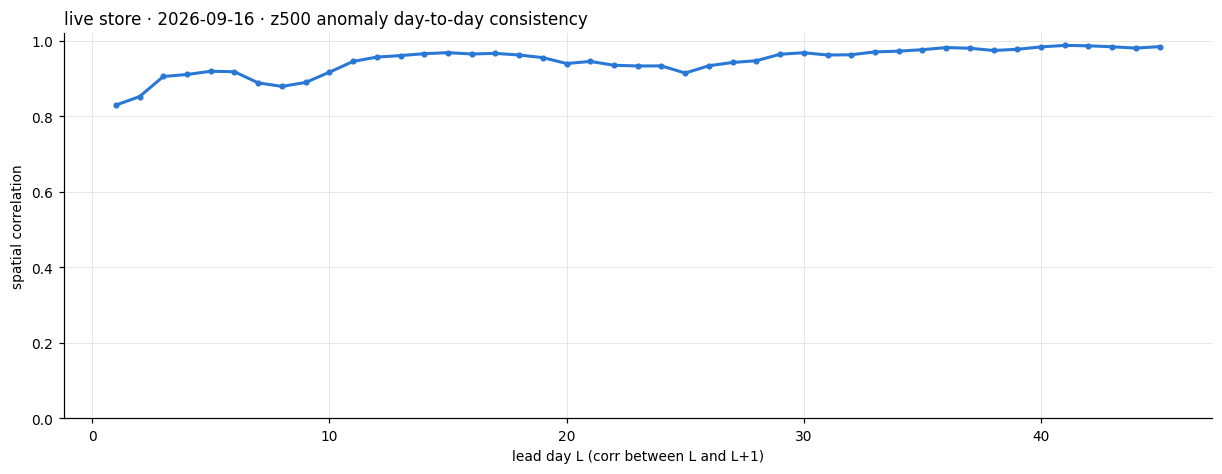

15 of 15 live issuances carry all 46 leads


In [6]:
ms = live['mean_stddev']['air_temperature']
counts = {}
for init, slot in live_inits.items():
    sub = ms.isel(reference_time=slot, latitude=slice(None, None, 12), longitude=slice(None, None, 12)).values
    counts[init] = int(np.isfinite(sub).any(axis=(1, 2)).sum())

LIVE_INIT, LIVE_SLOT = live_inits.index[-1], int(live_inits.iloc[-1])
live_cube = z500(live, LIVE_SLOT)

fig, ax = plt.subplots(figsize=(11, 4.2), layout='constrained')
ax.plot(STEPS[:-1], lead_corr(live_cube), color=BLUE, lw=2, marker='o', ms=3)
ax.set_ylim(0, 1.02); ax.set_xlabel('lead day L (corr between L and L+1)'); ax.set_ylabel('spatial correlation')
ax.set_title(f'live store · {LIVE_INIT:%Y-%m-%d} · z500 anomaly day-to-day consistency', loc='left')
plt.show()
print(f"{sum(v == 46 for v in counts.values())} of {len(counts)} live issuances carry all 46 leads")

---
## 2 · Hindcast: before and after the rerun, through snapshot history

Icechunk keeps every commit. The re-ingest of the 81 re-run issuances started with `2026-05-16` on 2026-09-15; the commit *before* it is the store as it stood with the stale cells. We open that snapshot read-only next to `main` and compare one issuance that had 24 stale leads.

The recompute of 2026-09-03 had already set the stale **anomaly** cells to NaN (that mask is how the stale leads were catalogued), while `mean_stddev` still held the stale values. To show what the stale anomaly *looked like*, we rebuild it as `mean_before − (mean_after − anomaly_after)`: the same fixed climatology applied to the stale mean field.

In [7]:
anc = list(hind_repo.ancestry(branch='main'))
first_rerun = max(i for i, s in enumerate(anc) if s.message.startswith('merge 46 forks for 2026-05-16'))   # oldest re-ingest commit of the rerun
before_snap = anc[first_rerun + 1]
print(f"main head       : {anc[0].written_at:%Y-%m-%d %H:%MZ}  {anc[0].message}")
print(f"first rerun     : {anc[first_rerun].written_at:%Y-%m-%d %H:%MZ}  {anc[first_rerun].message}")
print(f"before snapshot : {before_snap.written_at:%Y-%m-%d %H:%MZ}  {before_snap.message}  ({before_snap.id})")
print(f"rerun commits since then: {first_rerun}")

_, _, before, _ = open_store('Spire/saifs-s2s-hindcast', snapshot_id=before_snap.id)

RERUN = pd.Timestamp('2026-05-20'); PREV = pd.Timestamp('2026-05-19')
slot, slot_prev = int(hind_inits[RERUN]), int(hind_inits[PREV])
anom_after, mean_after, mean_before = z500(hind, slot), z500_mean(hind, slot), z500_mean(before, slot)
anom_before_raw = z500(before, slot)
stale = [L + 1 for L in range(len(STEPS)) if np.isnan(anom_before_raw[L]).all()]
anom_before = mean_before - (mean_after - anom_after)
print(f"{RERUN:%Y-%m-%d}: slot {slot}, stale leads before the rerun: {len(stale)} → {stale}")

main head       : 2026-09-16 12:07Z  merge 46 forks for 2026-08-09T00:00:00
first rerun     : 2026-09-15 20:06Z  merge 46 forks for 2026-05-16T00:00:00
before snapshot : 2026-09-15 05:28Z  merge 46 forks for 2026-08-16T00:00:00  (0YTVMRV9JDBQ8WPSVBS0)
rerun commits since then: 82


  2026-09-16T14:33:36.510630Z  WARN aws_runtime::env_config::normalize: profile `[default]` ignored because `[profile default]` was found which takes priority
    at /Users/runner/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-runtime-1.7.2/src/env_config/normalize.rs:136



2026-05-20: slot 139, stale leads before the rerun: 24 → [1, 3, 4, 8, 9, 11, 16, 17, 18, 21, 22, 23, 24, 25, 26, 27, 28, 31, 34, 35, 37, 38, 39, 46]


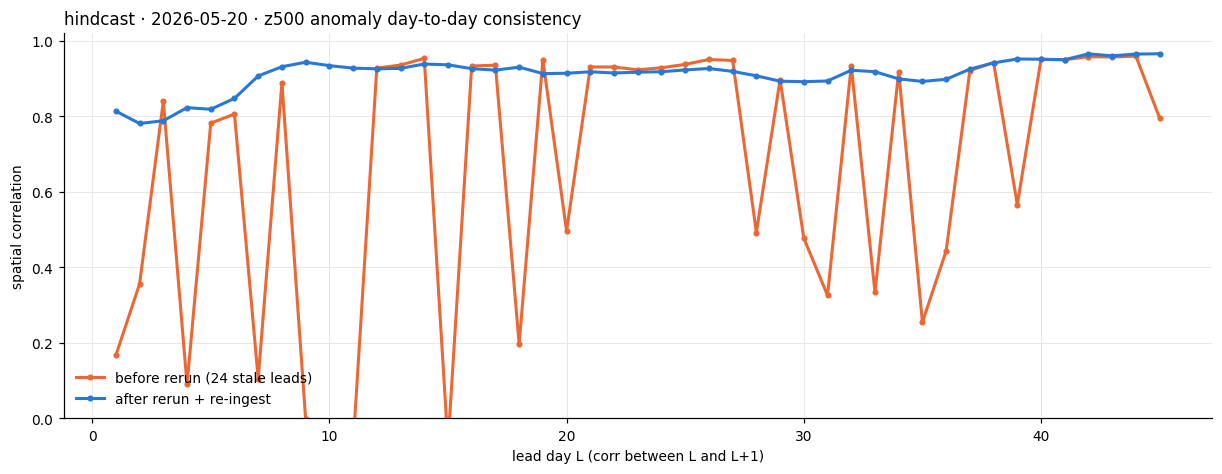

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.2), layout='constrained')
ax.plot(STEPS[:-1], lead_corr(anom_before), color=ORANGE, lw=2, marker='o', ms=3, label=f'before rerun ({len(stale)} stale leads)')
ax.plot(STEPS[:-1], lead_corr(anom_after), color=BLUE, lw=2, marker='o', ms=3, label='after rerun + re-ingest')
ax.set_ylim(0, 1.02); ax.set_xlabel('lead day L (corr between L and L+1)'); ax.set_ylabel('spatial correlation')
ax.set_title(f'hindcast · {RERUN:%Y-%m-%d} · z500 anomaly day-to-day consistency', loc='left'); ax.legend(frameon=False, loc='lower left')
plt.show()

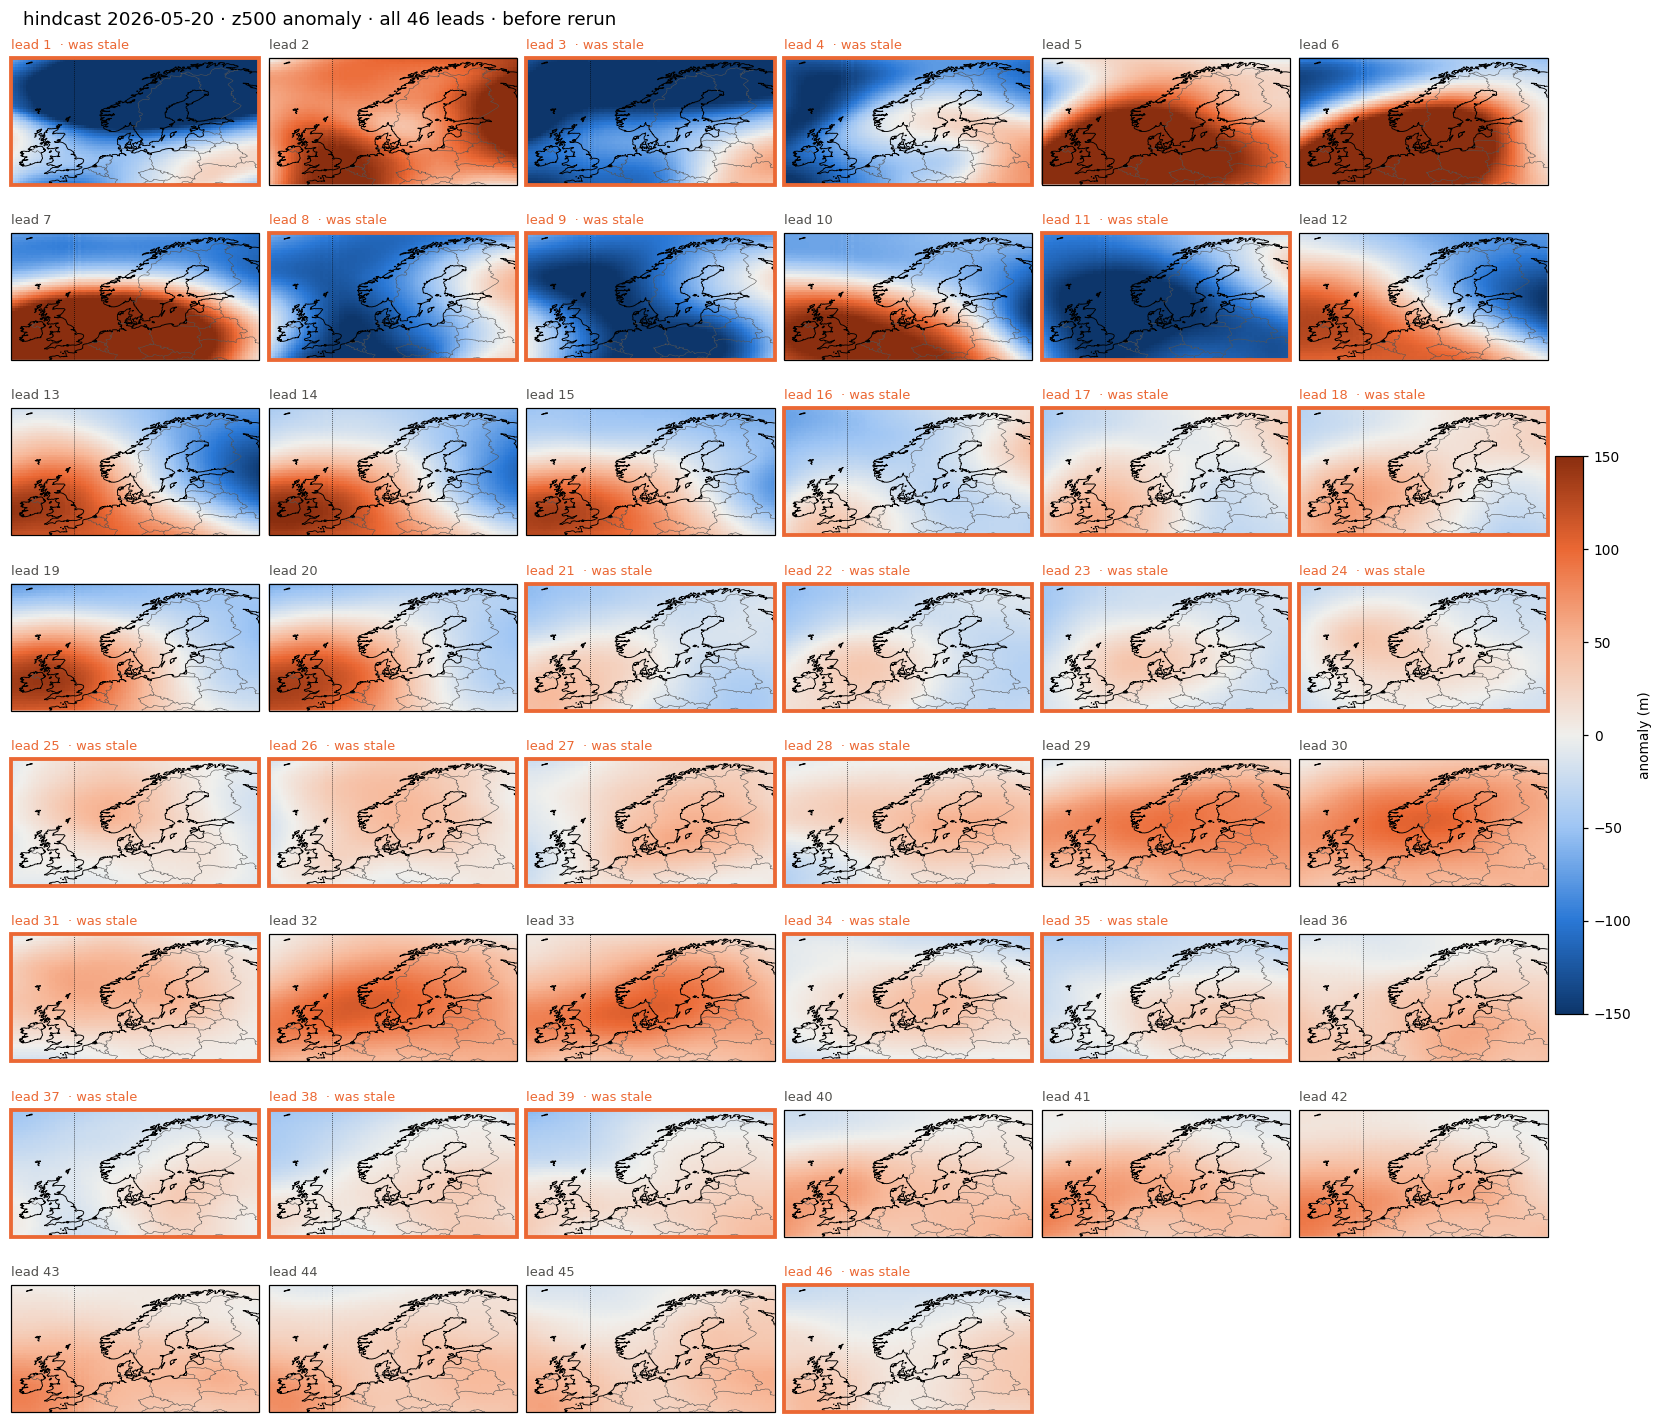

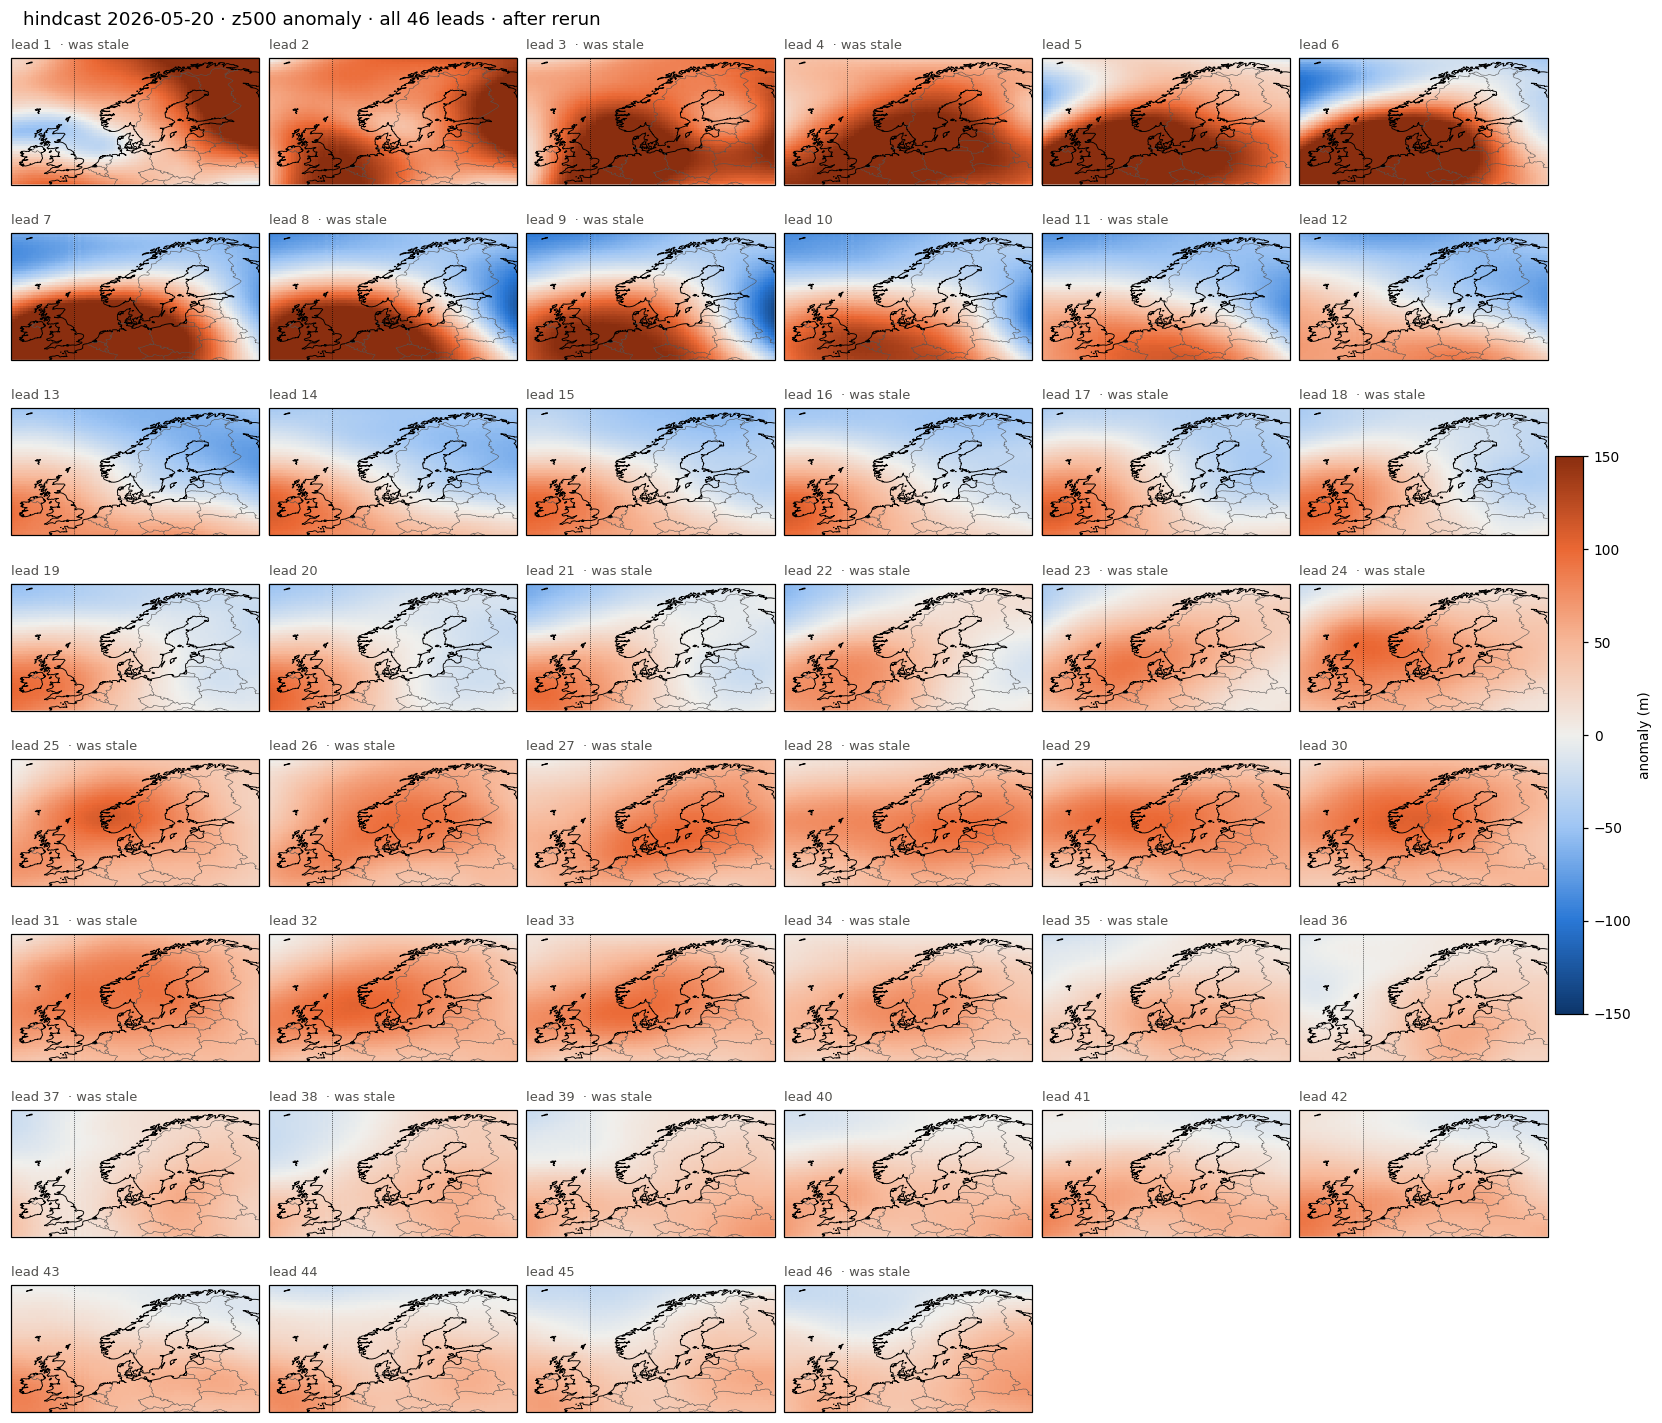

In [9]:
for label, cube, mark in (('before rerun', anom_before, True), ('after rerun', anom_after, False)):
    fig, axes = plt.subplots(8, 6, figsize=(15, 13), layout='constrained', subplot_kw=GEO)
    for i, ax in enumerate(axes.flat):
        L = i + 1
        if L > len(STEPS): ax.axis('off'); continue
        im = draw(ax, cube[L - 1]); is_stale = L in stale
        ax.set_title(f'lead {L}' + ('  · was stale' if is_stale else ''), fontsize=8.5, loc='left', color=ORANGE if (is_stale and mark) else INK2)
        if is_stale and mark:
            ax.spines['geo'].set_edgecolor(ORANGE); ax.spines['geo'].set_linewidth(2.5)
    fig.colorbar(im, ax=axes, shrink=0.4, pad=0.005, label='anomaly (m)')
    fig.suptitle(f'hindcast {RERUN:%Y-%m-%d} · z500 anomaly · all 46 leads · {label}', x=0.01, ha='left', fontsize=12)
    plt.show()

## 3 · Same valid day, consecutive issuances

Two forecasts issued one day apart, for the same target day, should nearly agree. Stale leads did not, because they were really the forecast issued 15 days earlier. After the rerun every pair agrees.

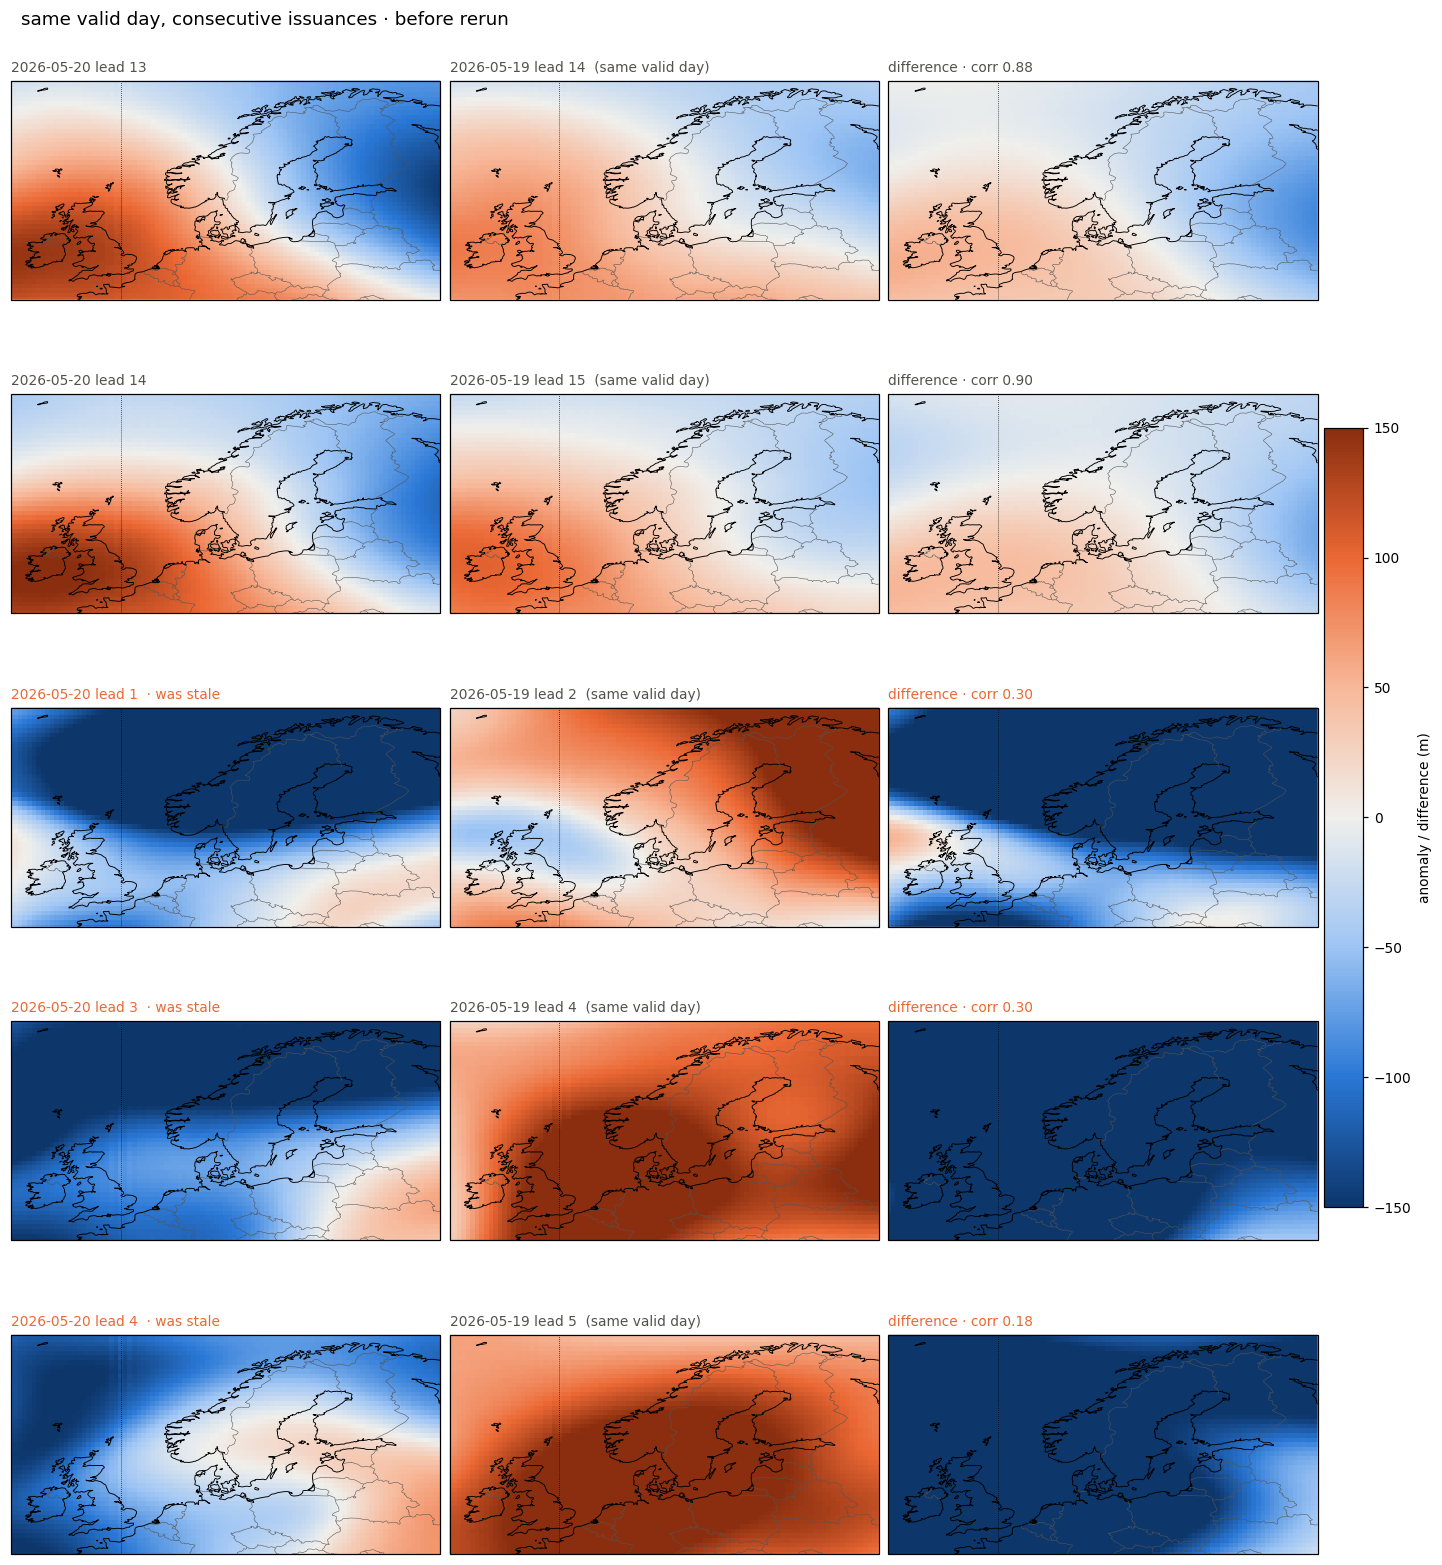

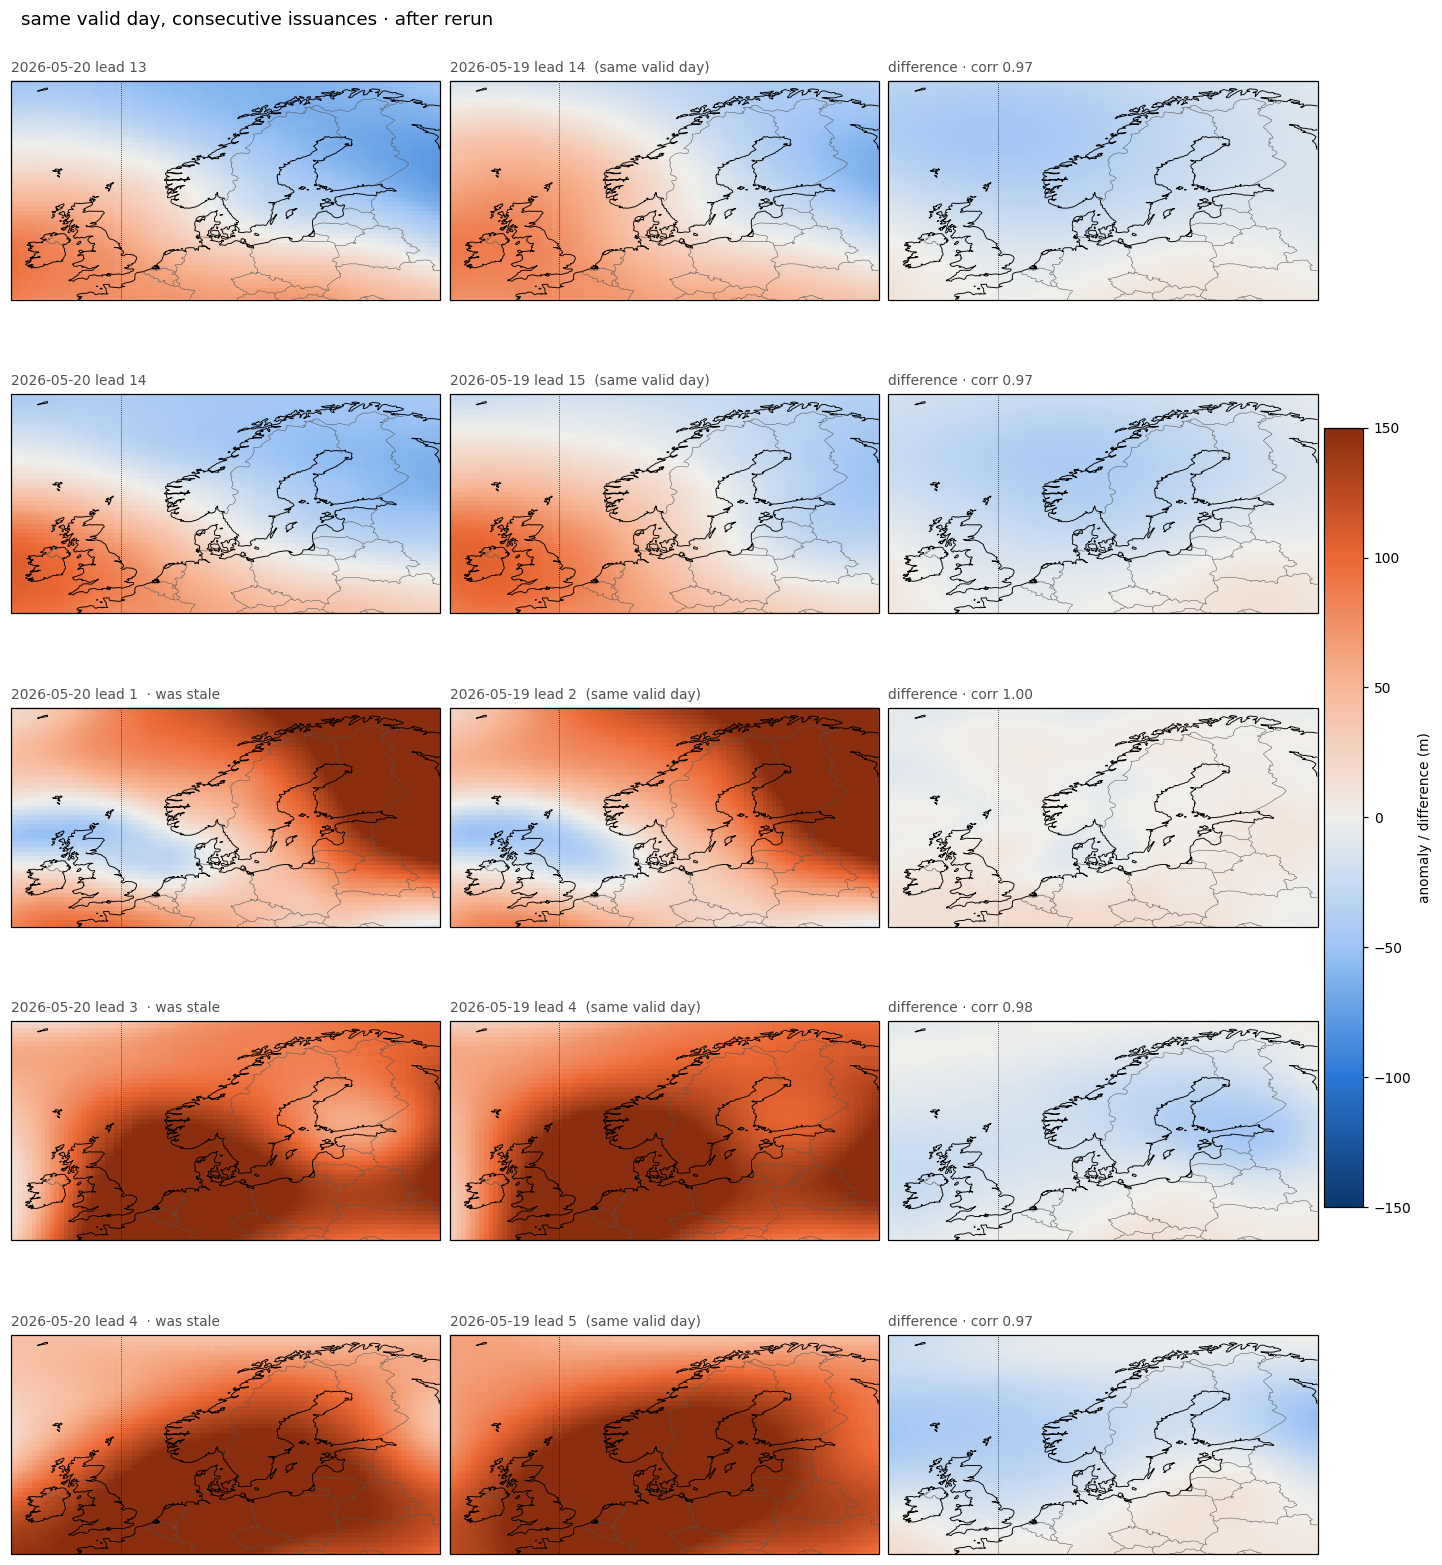

In [10]:
prev_cube = z500(hind, slot_prev)
fresh = [L for L in range(1, len(STEPS)) if L not in stale][6:8]; picks = fresh + [L for L in stale if L < len(STEPS)][:3]
for label, cube in (('before rerun', anom_before), ('after rerun', anom_after)):
    fig, axes = plt.subplots(len(picks), 3, figsize=(13, 2.9 * len(picks)), layout='constrained', subplot_kw=GEO)
    for r, L in enumerate(picks):
        a, b = cube[L - 1], prev_cube[L]; c = corr(a, b)
        draw(axes[r, 0], a); draw(axes[r, 1], b); im = draw(axes[r, 2], a - b)
        was = L in stale and label.startswith('before')
        axes[r, 0].set_title(f'{RERUN:%Y-%m-%d} lead {L}' + ('  · was stale' if L in stale else ''), fontsize=9, loc='left', color=ORANGE if was else INK2)
        axes[r, 1].set_title(f'{PREV:%Y-%m-%d} lead {L + 1}  (same valid day)', fontsize=9, loc='left', color=INK2)
        axes[r, 2].set_title(f'difference · corr {c:.2f}', fontsize=9, loc='left', color=ORANGE if c < 0.75 else INK2)
    fig.colorbar(im, ax=axes, shrink=0.5, pad=0.005, label='anomaly / difference (m)')
    fig.suptitle(f'same valid day, consecutive issuances · {label}', x=0.01, ha='left', fontsize=12)
    plt.show()

## 4 · Census across the re-run window

For a sample of the re-run issuances, count stale leads **before** (the recompute's NaN mask in the pre-rerun snapshot) and **after** (any lead byte-identical to the same lead 15 slots earlier, which is what a stale rolling-slot leftover looks like). Coarse sub-samples keep this to a few hundred small reads.

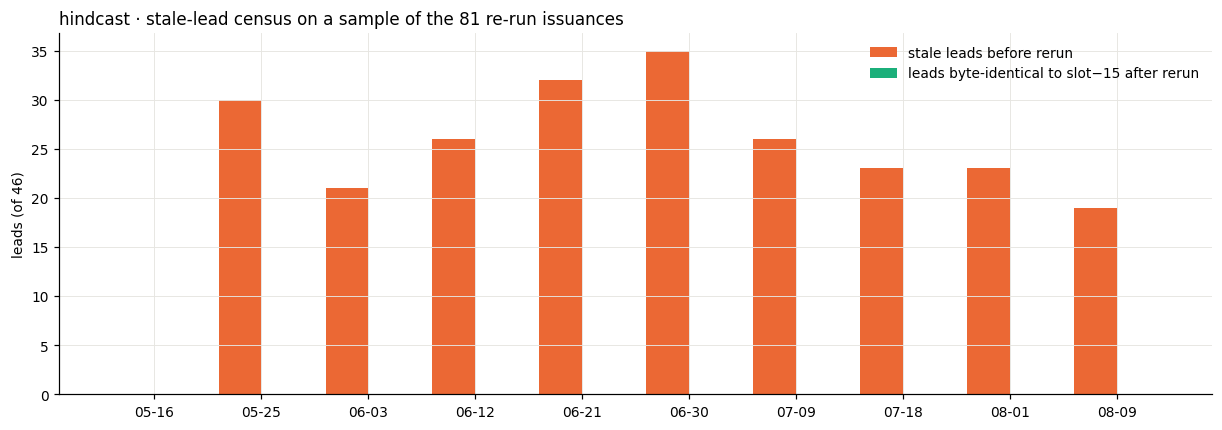

issuance,2026-05-16,2026-05-25,2026-06-03,2026-06-12,2026-06-21,2026-06-30,2026-07-09,2026-07-18,2026-08-01,2026-08-09
stale_before,0,30,21,26,32,35,26,23,23,19
stale_after,0,0,0,0,0,0,0,0,0,0


In [11]:
rerun_dates = list(pd.date_range('2026-05-16', '2026-07-19')) + list(pd.date_range('2026-07-25', '2026-08-09'))
sample = rerun_dates[::9] + [rerun_dates[-1]]
ms_after, an_before = hind['mean_stddev']['air_pressure_at_sea_level'], before['anomalies']['air_pressure_at_sea_level']
rows = []
for d in sample:
    s = int(hind_inits[d]); sub = dict(latitude=slice(None, None, 6), longitude=slice(None, None, 6))
    nb = int(np.isnan(an_before.isel(reference_time=s, **sub).values).all(axis=(1, 2)).sum())
    a_now, a_prev = ms_after.isel(reference_time=s, **sub).values, ms_after.isel(reference_time=s - 15, **sub).values
    na = int(sum(np.array_equal(a_now[L], a_prev[L], equal_nan=True) for L in range(len(STEPS))))
    rows.append((d, nb, na))
census = pd.DataFrame(rows, columns=['issuance', 'stale_before', 'stale_after']).set_index('issuance')
fig, ax = plt.subplots(figsize=(11, 3.8), layout='constrained'); x = np.arange(len(census))
ax.bar(x - 0.2, census.stale_before, width=0.4, color=ORANGE, label='stale leads before rerun')
ax.bar(x + 0.2, census.stale_after, width=0.4, color=GREEN, label='leads byte-identical to slot−15 after rerun')
ax.set_xticks(x); ax.set_xticklabels([d.strftime('%m-%d') for d in census.index]); ax.set_ylabel('leads (of 46)'); ax.legend(frameon=False)
ax.set_title('hindcast · stale-lead census on a sample of the 81 re-run issuances', loc='left'); plt.show()
census.T

## 5 · The prime-meridian seam: which part is fixed

Two seams were tangled together at 0° longitude:

- **Climatology wrap column** — the operational ERA5 climatology had a one-column offset at the wrap, so `mean − anomaly` stepped at 359.5°→0°. This is fixed store-wide; the dotted lines below sit at 1.
- **Model seam** — non-periodic longitude padding in the autoregressive model step puts a seam in the forecast fields themselves, growing with lead. **A rerun with the same model cannot remove this**; it shows identically on re-run and untouched issuances, and in the live store. It needs the model-side fix.

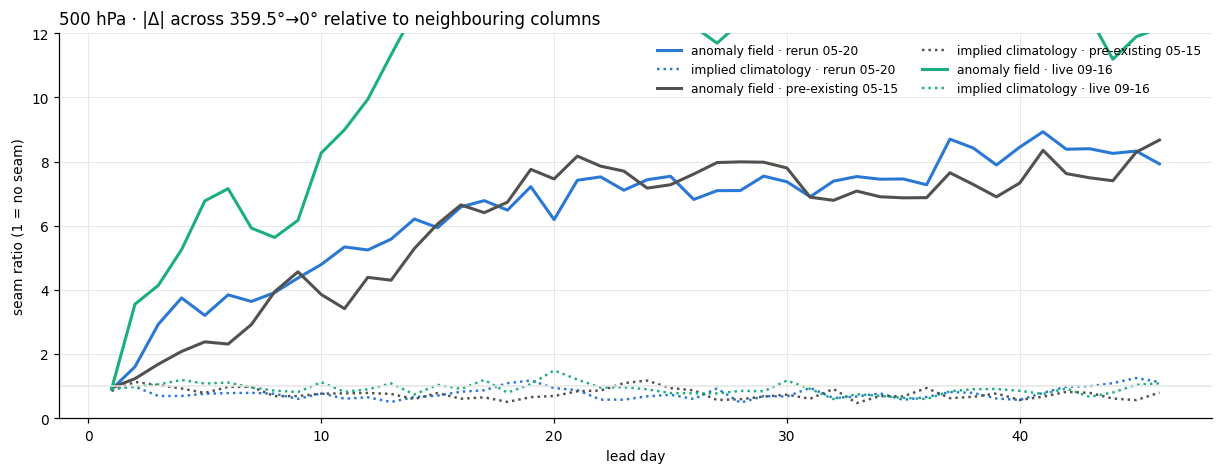

In [12]:
REF = pd.Timestamp('2026-05-15'); slot_ref = int(hind_inits[REF])
cases = {f'rerun {RERUN:%m-%d}': (hind, slot), f'pre-existing {REF:%m-%d}': (hind, slot_ref), f'live {LIVE_INIT:%m-%d}': (live, LIVE_SLOT)}
fig, ax = plt.subplots(figsize=(11, 4.2), layout='constrained')
for (tag, (g, s)), c in zip(cases.items(), (BLUE, INK2, GREEN)):
    a, m = z500(g, s), z500_mean(g, s)
    ax.plot(STEPS, seam_ratio(a), color=c, lw=2, label=f'anomaly field · {tag}')
    ax.plot(STEPS, seam_ratio(m - a), color=c, lw=1.6, ls=':', label=f'implied climatology · {tag}')
ax.axhline(1, color=GRID, lw=1); ax.set_ylim(0, 12); ax.set_xlabel('lead day'); ax.set_ylabel('seam ratio (1 = no seam)')
ax.set_title('500 hPa · |Δ| across 359.5°→0° relative to neighbouring columns', loc='left'); ax.legend(frameon=False, fontsize=8, ncol=2)
plt.show()

## 6 · One continuous regime record across both stores

The hindcast covers January to about 30 days ago; the live store covers the last 15 days. Together they give a continuous history of the CONUS weather-regime probabilities. We show the week-3 mean (leads 15–21), with the re-run window shaded, and the notebook's SQL question — *which regime is favoured at each lead 15–28 for the latest issuance* — answered from the live store.

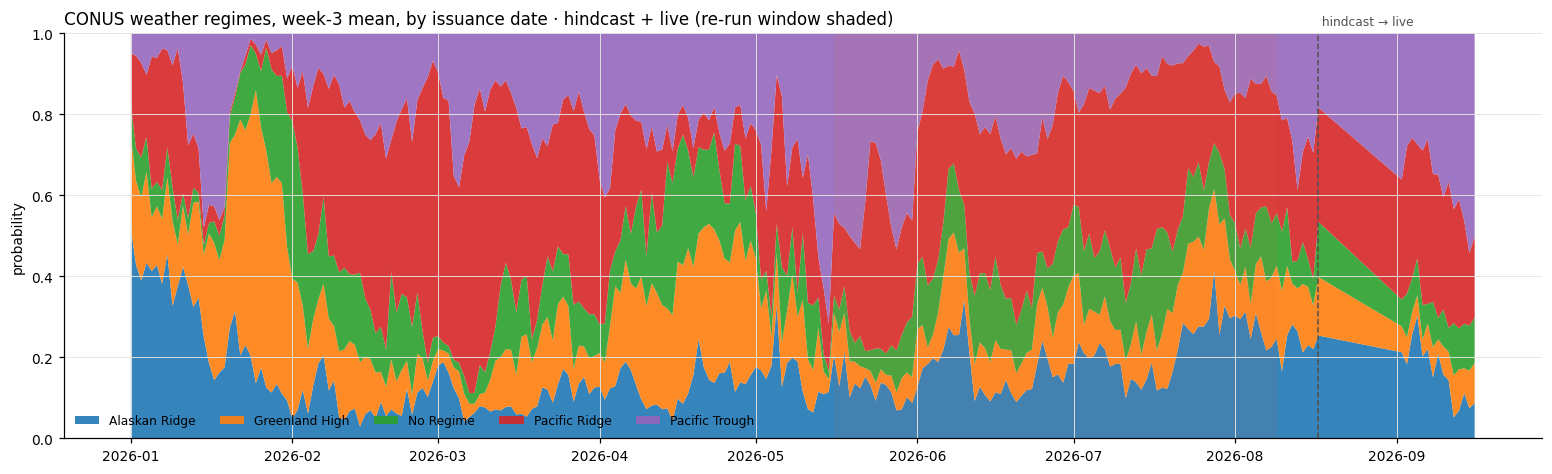

,favoured_regime,prob,all_regimes_sum
lead_days,,,
15,Pacific Trough,0.458,1.0
16,Pacific Trough,0.512,1.0
17,Pacific Trough,0.562,1.0
18,Pacific Trough,0.567,1.0
19,Pacific Trough,0.478,1.0
20,Pacific Trough,0.498,1.0
21,Pacific Trough,0.428,1.0
22,Pacific Trough,0.408,1.0
23,Pacific Trough,0.433,1.0


In [13]:
def regime_series(groups, inits, leads=slice(14, 21)):
    da = groups['regimes']['conus']
    names = [str(n) for n in groups['regimes']['conus_regime'].values] if 'conus_regime' in groups['regimes'] else [f'regime {i}' for i in range(da.shape[-1])]
    vals = np.stack([da.isel(reference_time=int(s), step=leads).mean('step').values for s in inits.values])
    return pd.DataFrame(vals, index=inits.index, columns=names)

rs = pd.concat([regime_series(hind, hind_inits), regime_series(live, live_inits)]).sort_index()
rs = rs[~rs.index.duplicated(keep='last')]
fig, ax = plt.subplots(figsize=(14, 4.2), layout='constrained')
ax.stackplot(rs.index, [rs[c].values for c in rs.columns], labels=rs.columns, alpha=0.9)
ax.axvspan(pd.Timestamp('2026-05-16'), pd.Timestamp('2026-08-09'), color=ORANGE, alpha=0.08, lw=0)
ax.axvline(hind_inits.index[-1], color=INK2, lw=1, ls='--'); ax.text(hind_inits.index[-1], 1.02, ' hindcast → live', color=INK2, fontsize=8)
ax.set_ylim(0, 1); ax.set_ylabel('probability'); ax.set_title('CONUS weather regimes, week-3 mean, by issuance date · hindcast + live (re-run window shaded)', loc='left')
ax.legend(frameon=False, ncol=5, loc='lower left', fontsize=8); plt.show()

fav = live['regimes']['conus'].isel(reference_time=LIVE_SLOT, step=slice(14, 28)).values
names = list(rs.columns)
pd.DataFrame({'lead_days': range(15, 29), 'favoured_regime': [names[int(np.nanargmax(p))] for p in fav],
              'prob': np.round(np.nanmax(fav, axis=1), 3), 'all_regimes_sum': np.round(np.nansum(fav, axis=1), 3)}).set_index('lead_days')

---
## Takeaways

- **Live store**: every issuance in the window carries 46/46 leads and evolves smoothly lead to lead; the dropped-lead defect is gone.
- **Hindcast**: the 81 re-run issuances replace 1,979 stale cells; consecutive leads and consecutive issuances agree again. Snapshot history lets anyone reproduce the before/after.
- **Climatology seam** at the prime meridian: fixed. **Model seam**: still present on every issuance and awaits the model-side fix.
- The two stores read as one continuous record through the Arraylake catalog.